# 05 — Generic Bound Kerr Orbit and Animation

The earlier notebooks used exact circular orbits for validation. This notebook
moves to a genuinely three-dimensional **generic bound timelike Kerr
geodesic**, similar to the precessing trajectories often shown in visualizations
of Kerr spacetime.

A generic bound Kerr orbit has independent radial, polar, and azimuthal
motions. Their frequencies are generally unequal, so the orbit does not close
after one revolution. Instead it precesses and traces a torus-like region.

This is not dissipative inspiral: the test particle follows a geodesic and
conserves its energy and angular momentum.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from kerr_schild_geodesics import (
    kerr_radius,
    normalization,
    energy_lz,
    solve_ut_timelike,
    horizon_radius,
)
from kerr_schild_geodesics.integrators import integrate_rk4
from kerr_schild_geodesics.orbits import circular_equatorial_state

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


## 1. Initial data

We use

\[
M=1,\qquad a=0.8M,\qquad r_0=8M.
\]

We start from the spatial four-velocity of a prograde circular orbit and
perturb it in two ways:

- reduce the azimuthal component to \(85\%\) of the circular value;
- add a vertical component equal to \(20\%\) of that circular azimuthal
  component.

The timelike normalization equation is then solved again for \(u^t\).

These initial data produce a bound, inclined Kerr geodesic rather than an exact
circular orbit.


In [2]:
M = 1.0
a = 0.8
r0 = 8.0

base = circular_equatorial_state(r0, M, a, sense=+1)

ux0 = 0.0
uy0 = 0.85 * base[6]
uz0 = 0.20 * base[6]

ut0 = solve_ut_timelike(
    base[1], base[2], base[3],
    ux0, uy0, uz0,
    M, a,
)

state0 = np.array([
    0.0,
    base[1], base[2], base[3],
    ut0, ux0, uy0, uz0,
])

print("initial normalization =", normalization(state0, M, a))
print("initial E, Lz =", energy_lz(state0, M, a))


initial normalization = -1.0000000000000002
initial E, Lz = (0.9241764888416777, 2.6743535655890907)


## 2. Integrate the orbit

In [3]:
h = 0.02
lambda_end = 1800.0
n_steps = int(lambda_end / h)

trajectory = integrate_rk4(state0, h, n_steps, M, a)

print("number of RK4 steps =", n_steps)


number of RK4 steps = 90000


## 3. Verify that the orbit is bound and numerically well conserved

In [4]:
sample = trajectory[::500]

r_values = np.array([
    kerr_radius(s[1], s[2], s[3], a)
    for s in sample
])

norm_values = np.array([
    normalization(s, M, a)
    for s in sample
])

EL_values = np.array([
    energy_lz(s, M, a)
    for s in sample
])

print("radial range =", r_values.min(), "to", r_values.max())
print("z range =", trajectory[:,3].min(), "to", trajectory[:,3].max())
print("max |norm+1| =", np.max(np.abs(norm_values + 1.0)))
print("max |E-E0| =", np.max(np.abs(EL_values[:,0] - EL_values[0,0])))
print("max |Lz-Lz0| =", np.max(np.abs(EL_values[:,1] - EL_values[0,1])))


radial range = 3.8716553872771984 to 7.999999999999999
z range = -1.9571670298727593 to 1.96363334583533
max |norm+1| = 7.380107636123512e-11
max |E-E0| = 6.107181427239539e-11
max |Lz-Lz0| = 3.5677816256907136e-10


## 4. Three-dimensional trajectory

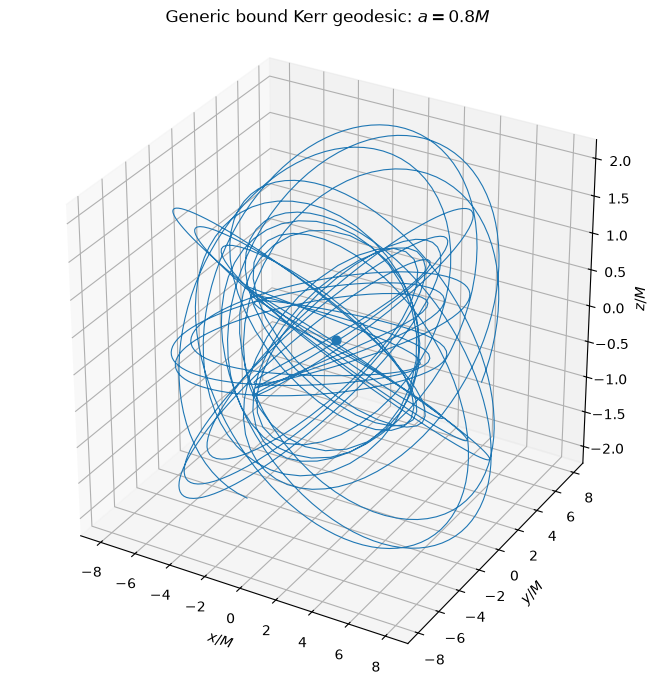

In [13]:
draw = trajectory[::60]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(draw[:,1], draw[:,2], draw[:,3], linewidth=0.8)
ax.scatter([0.0], [0.0], [0.0], s=40)

ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_zlabel(r"$z/M$")
ax.set_title(
    r"Generic bound Kerr geodesic: $a=0.8M$"
)
ax.set_box_aspect((1, 1, 1))

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "generic_bound_kerr_3d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 5. Top view

This view emphasizes apsidal precession in the orbital plane.

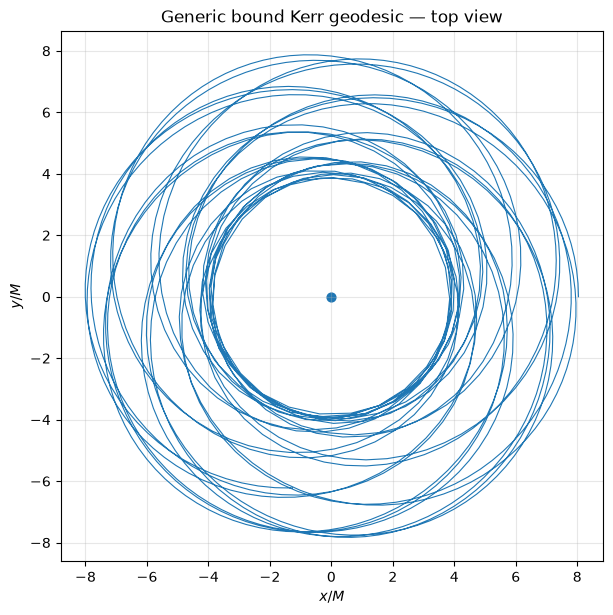

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(draw[:,1], draw[:,2], linewidth=0.8)
ax.scatter([0.0], [0.0], s=40)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title("Generic bound Kerr geodesic — top view")
ax.grid(True, alpha=0.3)

fig.savefig(
    FIGURE_DIR / "generic_bound_kerr_xy.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 6. Side view

The side view makes the polar oscillation and orbital inclination obvious.

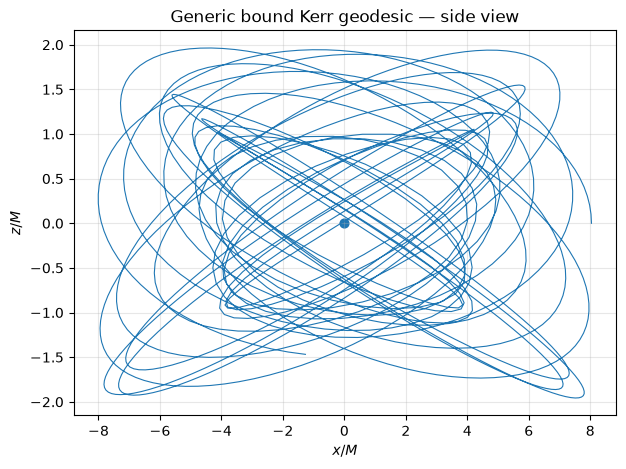

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(draw[:,1], draw[:,3], linewidth=0.8)
ax.scatter([0.0], [0.0], s=40)
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$z/M$")
ax.set_title("Generic bound Kerr geodesic — side view")
ax.grid(True, alpha=0.3)

fig.savefig(
    FIGURE_DIR / "generic_bound_kerr_xz.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 7. Animated GIF

The full trajectory is shown faintly in the background while a short moving
segment follows the particle. This produces a compact visualization suitable
for the repository README.


In [16]:
# ------------------------------------------------------------
# Smooth, slower animation of the generic bound Kerr orbit
# ------------------------------------------------------------

# Keep more points for the animation.
# trajectory[::100] means: use every 100th RK4 point.
# With h = 0.02, displayed candidate points are separated by:
# 100 * 0.02 = 2 affine-parameter units.
anim_data = trajectory[::100]

xv = anim_data[:, 1]
yv = anim_data[:, 2]
zv = anim_data[:, 3]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw the complete orbit faintly in the background.
ax.plot(
    xv,
    yv,
    zv,
    alpha=0.18,
    linewidth=0.7
)

# Moving recent trajectory segment.
moving_line, = ax.plot(
    [],
    [],
    [],
    linewidth=1.35
)

# Moving particle marker.
moving_point, = ax.plot(
    [],
    [],
    [],
    marker="o",
    linestyle="None",
    markersize=5
)

# Black-hole location.
ax.scatter(
    [0.0],
    [0.0],
    [0.0],
    s=42
)

ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_zlabel(r"$z/M$")

ax.set_title(
    "Generic bound Kerr geodesic"
)

ax.set_box_aspect((1, 1, 1))

# ------------------------------------------------------------
# Axis limits
# ------------------------------------------------------------

pad = 0.5

ax.set_xlim(
    xv.min() - pad,
    xv.max() + pad
)

ax.set_ylim(
    yv.min() - pad,
    yv.max() + pad
)

ax.set_zlim(
    zv.min() - pad,
    zv.max() + pad
)

# ------------------------------------------------------------
# Animation settings
# ------------------------------------------------------------

# Use up to 600 displayed frames.
# At 15 fps this gives approximately:
#
# 600 / 15 = 40 seconds
#
# which is much easier to watch than the old ~12 second GIF.
n_frames = min(
    600,
    len(xv)
)

frame_indices = np.linspace(
    1,
    len(xv) - 1,
    n_frames,
    dtype=int
)

# Number of recent animation points retained as the moving tail.
tail = 90


def update(frame_number):

    i = frame_indices[frame_number]

    # Beginning of the moving tail
    j = max(
        0,
        i - tail
    )

    # Update trajectory tail
    moving_line.set_data(
        xv[j:i+1],
        yv[j:i+1]
    )

    moving_line.set_3d_properties(
        zv[j:i+1]
    )

    # Update particle position
    moving_point.set_data(
        [xv[i]],
        [yv[i]]
    )

    moving_point.set_3d_properties(
        [zv[i]]
    )

    return moving_line, moving_point


# ------------------------------------------------------------
# Create animation
# ------------------------------------------------------------

fps = 15

animation = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False,
)

# ------------------------------------------------------------
# Save GIF
# ------------------------------------------------------------

gif_path = (
    FIGURE_DIR
    / "generic_bound_kerr_orbit.gif"
)

animation.save(
    gif_path,
    writer=PillowWriter(
        fps=fps
    )
)

plt.close(fig)

print("saved:", gif_path)
print("number of frames:", n_frames)
print(
    "playback duration:",
    n_frames / fps,
    "seconds"
)

saved: /home/allanur/Desktop/kerr-schild-geodesics/figures/generic_bound_kerr_orbit.gif
number of frames: 600
playback duration: 40.0 seconds


## Physical interpretation

The trajectory is bound but noncircular and non-equatorial. Its radial,
vertical, and azimuthal motions have different characteristic frequencies, so
the orbit precesses instead of closing into a single ellipse.

This is qualitatively the type of generic Kerr geodesic shown in many
visualizations of test-particle motion around a rotating black hole. It should
not be confused with a radiation-driven inspiral: no dissipative force has been
included here.


In [18]:
# ------------------------------------------------------------
# Smooth animation with the Kerr event horizon
# ------------------------------------------------------------

# Keep more points than the original animation.
# With h = 0.02, this corresponds to one candidate animation
# point every 2 affine-parameter units.
anim_data = trajectory[::100]

xv = anim_data[:, 1]
yv = anim_data[:, 2]
zv = anim_data[:, 3]


# ============================================================
# Construct the Kerr outer event horizon
# ============================================================

# Outer Kerr horizon:
#
# r_+ = M + sqrt(M^2 - a^2)
#
r_plus = M + np.sqrt(M**2 - a**2)

# In Cartesian Kerr-Schild coordinates, a constant-r surface is
#
# (x^2 + y^2)/(r^2 + a^2) + z^2/r^2 = 1
#
# Therefore the horizon has:
#
# equatorial semi-axis = sqrt(r_+^2 + a^2)
# polar semi-axis      = r_+
#
horizon_equatorial_radius = np.sqrt(
    r_plus**2 + a**2
)

horizon_polar_radius = r_plus


# Moderate surface resolution keeps GIF rendering reasonable.
theta = np.linspace(
    0.0,
    np.pi,
    24
)

phi = np.linspace(
    0.0,
    2.0 * np.pi,
    48
)

theta_grid, phi_grid = np.meshgrid(
    theta,
    phi
)


# Parametric Kerr horizon surface
xh = (
    horizon_equatorial_radius
    * np.sin(theta_grid)
    * np.cos(phi_grid)
)

yh = (
    horizon_equatorial_radius
    * np.sin(theta_grid)
    * np.sin(phi_grid)
)

zh = (
    horizon_polar_radius
    * np.cos(theta_grid)
)


# ============================================================
# Set up 3D figure
# ============================================================

fig = plt.figure(
    figsize=(7, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Orthographic projection reduces perspective distortion.
ax.set_proj_type("ortho")


# ------------------------------------------------------------
# Full orbit shown faintly in the background
# ------------------------------------------------------------

ax.plot(
    xv,
    yv,
    zv,
    alpha=0.18,
    linewidth=0.7
)


# ------------------------------------------------------------
# Kerr event horizon
# ------------------------------------------------------------

ax.plot_surface(
    xh,
    yh,
    zh,
    alpha=0.70,
    linewidth=0.0,
    antialiased=True
)


# ------------------------------------------------------------
# Moving trajectory tail
# ------------------------------------------------------------

moving_line, = ax.plot(
    [],
    [],
    [],
    linewidth=1.35
)


# ------------------------------------------------------------
# Moving particle
# ------------------------------------------------------------

moving_point, = ax.plot(
    [],
    [],
    [],
    marker="o",
    linestyle="None",
    markersize=5
)


# ============================================================
# Figure labels
# ============================================================

ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_zlabel(r"$z/M$")

ax.set_title(
    rf"Generic bound Kerr geodesic: "
    rf"$a={a:.1f}M$"
)


# ============================================================
# Axis limits
# ============================================================

pad = 0.5

xmin = xv.min() - pad
xmax = xv.max() + pad

ymin = yv.min() - pad
ymax = yv.max() + pad

zmin = zv.min() - pad
zmax = zv.max() + pad


ax.set_xlim(
    xmin,
    xmax
)

ax.set_ylim(
    ymin,
    ymax
)

ax.set_zlim(
    zmin,
    zmax
)


# ------------------------------------------------------------
# Preserve equal physical scale in x, y, and z
# ------------------------------------------------------------
#
# This is important.
#
# The x/y range is much larger than the z range.
# Using (1,1,1) would stretch z visually and make
# the Kerr horizon look artificially egg-shaped.
#

x_range = xmax - xmin
y_range = ymax - ymin
z_range = zmax - zmin

ax.set_box_aspect(
    (
        x_range,
        y_range,
        z_range
    )
)


# ============================================================
# Animation settings
# ============================================================

fps = 15

# 450 frames / 15 fps = 30 seconds.
n_frames = min(
    450,
    len(xv)
)

frame_indices = np.linspace(
    1,
    len(xv) - 1,
    n_frames,
    dtype=int
)


# Number of recent points retained behind the particle
tail = 90


def update(frame_number):

    i = frame_indices[frame_number]

    j = max(
        0,
        i - tail
    )

    # Moving trajectory tail
    moving_line.set_data(
        xv[j:i+1],
        yv[j:i+1]
    )

    moving_line.set_3d_properties(
        zv[j:i+1]
    )

    # Moving particle
    moving_point.set_data(
        [xv[i]],
        [yv[i]]
    )

    moving_point.set_3d_properties(
        [zv[i]]
    )

    return (
        moving_line,
        moving_point
    )


# ============================================================
# Create animation
# ============================================================

animation = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)


# ============================================================
# Save GIF
# ============================================================

gif_path = (
    FIGURE_DIR
    / "generic_bound_kerr_orbit.gif"
)

animation.save(
    gif_path,
    writer=PillowWriter(
        fps=fps
    )
)

plt.close(fig)


# ============================================================
# Print useful information
# ============================================================

print("saved:", gif_path)

print(
    "Kerr outer horizon r_+ =",
    r_plus,
    "M"
)

print(
    "horizon equatorial semi-axis =",
    horizon_equatorial_radius,
    "M"
)

print(
    "horizon polar semi-axis =",
    horizon_polar_radius,
    "M"
)

print(
    "axis ranges:",
    x_range,
    y_range,
    z_range
)

print(
    "animation duration =",
    n_frames / fps,
    "seconds"
)

saved: /home/allanur/Desktop/kerr-schild-geodesics/figures/generic_bound_kerr_orbit.gif
Kerr outer horizon r_+ = 1.5999999999999999 M
horizon equatorial semi-axis = 1.7888543819998317 M
horizon polar semi-axis = 1.5999999999999999 M
axis ranges: 17.048997677959456 16.695471729329668 4.918227193787154
animation duration = 30.0 seconds
